In [2]:
import torch
import numpy as np
import pandas as pd
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split


# Use MPS if available (Apple Silicon), otherwise CPU
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [3]:
df = pd.read_csv('../data/processed/combined_base_data.csv')
df['datetime_posted'] = pd.to_datetime(df['datetime_posted'], utc=True, format='mixed')
df = df.dropna(subset=['title']).copy()

# Reconstruct the same split as the modeling notebook
# If your modeling notebook used stratified, use that here too

train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['is_fox'])
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

X_train = train['title'].tolist()
X_test = test['title'].tolist()
y_train = train['is_fox'].tolist()
y_test = test['is_fox'].tolist()

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Train Fox%: {np.mean(y_train):.2%} | Test Fox%: {np.mean(y_test):.2%}')

Train: 3040 | Test: 761
Train Fox%: 52.63% | Test Fox%: 52.56%


In [4]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Test it on one headline so you can see what it produces
sample = X_train[0]
encoded = tokenizer(sample, truncation=True, max_length=64, padding='max_length', return_tensors='pt')

print('Headline:', sample)
print('Input IDs:', encoded['input_ids'])
print('Attention mask:', encoded['attention_mask'])
print('Tokens:', tokenizer.convert_ids_to_tokens(encoded['input_ids'][0]))

Headline: Rapper charged with coronavirus benefit fraud after boasting in song about benefit fraud
Input IDs: tensor([[  101, 10687,  5338,  2007, 21887, 23350,  5770,  9861,  2044,  8945,
         14083,  2075,  1999,  2299,  2055,  5770,  9861,   102,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0]])
Attention mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
Tokens: ['[CLS]', 'rapper', 'charged', 'with', 'corona', '##virus', 'benefit', 'fraud', 'after', 'bo', '##ast', '##ing', 'in', 'song', 'abou

In [5]:
class HeadlineDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding='max_length',
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

train_dataset = HeadlineDataset(X_train, y_train, tokenizer)
test_dataset = HeadlineDataset(X_test, y_test, tokenizer)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Train dataset size: 3040
Test dataset size: 761


In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 95
Test batches: 12


In [7]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10764.29it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 66,955,010
Trainable parameters: 66,955,010


In [8]:
num_epochs = 3
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f'Total training steps: {total_steps}')
print(f'Warmup steps: {int(0.1 * total_steps)}')

Total training steps: 285
Warmup steps: 28


In [9]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += len(labels)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=-1)

            correct += (preds == labels).sum().item()
            total += len(labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return correct / total, all_preds, all_labels

In [ ]:
from sklearn.metrics import classification_report
import os

os.makedirs("models", exist_ok = True)

best_acc = 0
history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    test_acc, test_preds, test_labels = evaluate(model, test_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'Loss: {train_loss:.4f} | '
          f'Train acc: {train_acc:.4f} | '
          f'Test acc: {test_acc:.4f}')

    if test_acc > best_acc:
        best_acc = test_acc
        best_preds = test_preds
        best_labels = test_labels
        torch.save(model.state_dict(), 'models/distilbert_best_v1.pt')
        print(f'  -> New best model saved ({best_acc:.4f})')

print(f'\nBest test accuracy: {best_acc:.4f}')
print(classification_report(best_labels, best_preds, target_names=['NBC', 'Fox']))

Epoch 1/3 | Loss: 0.5852 | Train acc: 0.6993 | Test acc: 0.7806
  -> New best model saved (0.7806)
Epoch 2/3 | Loss: 0.3903 | Train acc: 0.8362 | Test acc: 0.8239
  -> New best model saved (0.8239)
Epoch 3/3 | Loss: 0.2927 | Train acc: 0.8911 | Test acc: 0.8213

Best test accuracy: 0.8239
              precision    recall  f1-score   support

         NBC       0.84      0.78      0.81       361
         Fox       0.81      0.86      0.84       400

    accuracy                           0.82       761
   macro avg       0.83      0.82      0.82       761
weighted avg       0.82      0.82      0.82       761



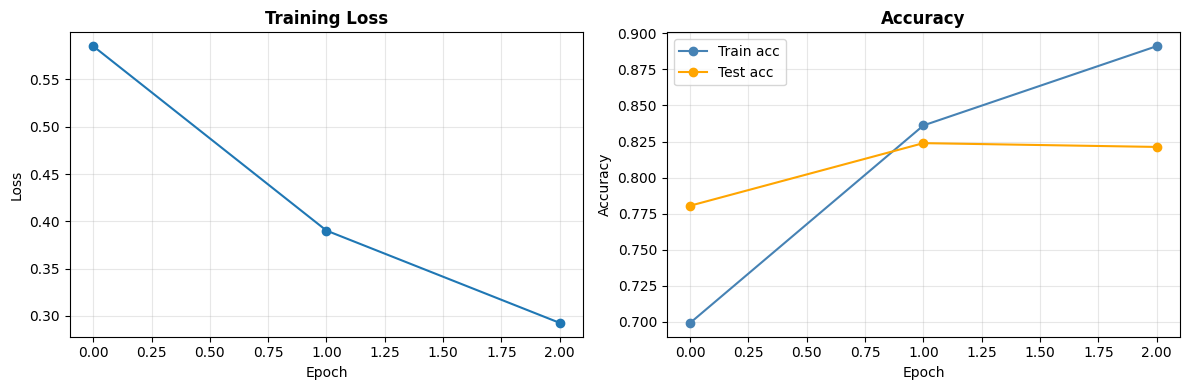

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], marker='o', label='Train loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], marker='o', label='Train acc', color='steelblue')
axes[1].plot(history['test_acc'], marker='o', label='Test acc', color='orange')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Run with lower learning rate and more epochs for better performance (but longer training time)

# Reinitialize model from pretrained weights — fresh start
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
model = model.to(device)

# Optimizer and scheduler
num_epochs = 5
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

best_acc = 0
history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    test_acc, test_preds, test_labels = evaluate(model, test_loader, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'Loss: {train_loss:.4f} | '
          f'Train acc: {train_acc:.4f} | '
          f'Test acc: {test_acc:.4f}')
    if test_acc > best_acc:
        best_acc = test_acc
        best_preds = test_preds
        best_labels = test_labels
        torch.save(model.state_dict(), 'models/distilbert_best_v2.pt')
        print(f'  -> New best model saved ({best_acc:.4f})')

print(f'\nBest test accuracy: {best_acc:.4f}')
print(classification_report(best_labels, best_preds, target_names=['NBC', 'Fox']))

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6816.57it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/5 | Loss: 0.6512 | Train acc: 0.6105 | Test acc: 0.7254
  -> New best model saved (0.7254)
Epoch 2/5 | Loss: 0.4800 | Train acc: 0.7937 | Test acc: 0.7766
  -> New best model saved (0.7766)
Epoch 3/5 | Loss: 0.3715 | Train acc: 0.8490 | Test acc: 0.8081
  -> New best model saved (0.8081)
Epoch 4/5 | Loss: 0.3126 | Train acc: 0.8803 | Test acc: 0.8213
  -> New best model saved (0.8213)
Epoch 5/5 | Loss: 0.2863 | Train acc: 0.8911 | Test acc: 0.8226
  -> New best model saved (0.8226)

Best test accuracy: 0.8226
              precision    recall  f1-score   support

         NBC       0.79      0.85      0.82       361
         Fox       0.85      0.80      0.83       400

    accuracy                           0.82       761
   macro avg       0.82      0.82      0.82       761
weighted avg       0.82      0.82      0.82       761



In [18]:
# Continue training from where we left off — do NOT reinitialize
# The model already has the best weights, just extend training
num_extra_epochs = 3

for epoch in range(num_extra_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    test_acc, test_preds, test_labels = evaluate(model, test_loader, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    print(f'Epoch {len(history["test_acc"])}/8 | '
          f'Loss: {train_loss:.4f} | '
          f'Train acc: {train_acc:.4f} | '
          f'Test acc: {test_acc:.4f}')
    if test_acc > best_acc:
        best_acc = test_acc
        best_preds = test_preds
        best_labels = test_labels
        torch.save(model.state_dict(), 'models/distilbert_best_v2.pt')
        print(f'  -> New best model saved ({best_acc:.4f})')

print(f'\nBest test accuracy: {best_acc:.4f}')

Epoch 6/8 | Loss: 0.2728 | Train acc: 0.9033 | Test acc: 0.8226
Epoch 7/8 | Loss: 0.2693 | Train acc: 0.9026 | Test acc: 0.8226
Epoch 8/8 | Loss: 0.2751 | Train acc: 0.8961 | Test acc: 0.8226

Best test accuracy: 0.8226


## Add stylistic features to feature vector for DistillBERT

In [40]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from transformers import DistilBertTokenizer, DistilBertModel
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


In [41]:
# ── Data & tokenizer ──────────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/combined_base_data.csv')
df = df.dropna(subset=['title']).copy()

train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['is_fox'])
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

X_train = [t.strip() for t in train['title'].tolist()]
X_test = [t.strip() for t in test['title'].tolist()]
y_train = train['is_fox'].tolist()
y_test = test['is_fox'].tolist()

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Train Fox%: {np.mean(y_train):.2%} | Test Fox%: {np.mean(y_test):.2%}')

Train: 3040 | Test: 761
Train Fox%: 52.63% | Test Fox%: 52.56%


In [42]:
def compute_style_features(titles):
    """
    Compute style features from a list of headline strings.
    Returns a numpy array of shape (n, 6).
    Must be identical to what's used at inference time in preprocess.py.
    """
    titles = pd.Series(titles).fillna('')
    features = pd.DataFrame({
        'word_count': titles.str.split().str.len(),
        'char_count': titles.str.len(),
        'has_single_quotes': titles.str.contains(r"'[^']{1,40}'", regex=True).astype(float),
        'has_question': titles.str.endswith('?').astype(float),
        'has_colon': titles.str.contains(':', regex=False).astype(float),
        'has_allcaps': titles.str.contains(r'\b[A-Z]{3,}\b', regex=True).astype(float),
    })
    return features.values.astype(np.float32)

In [43]:
class HeadlineDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding='max_length',
            return_tensors='pt'
        )
        self.style_features = torch.tensor(
            compute_style_features(texts),
            dtype=torch.float32
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'style_features': self.style_features[idx],
            'labels': self.labels[idx],
        }

In [44]:
# Build datasets and dataloaders
train_dataset = HeadlineDataset(X_train, y_train, tokenizer, max_length=64)
test_dataset = HeadlineDataset(X_test, y_test, tokenizer, max_length=64)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f'Train dataset: {len(train_dataset)} | Train batches: {len(train_loader)}')
print(f'Test dataset:  {len(test_dataset)} | Test batches:  {len(test_loader)}')

Train dataset: 3040 | Train batches: 95
Test dataset:  761 | Test batches:  12


In [45]:
class DistilBertWithStyle(nn.Module):
    def __init__(self, num_style_features=6, dropout=0.3):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        
        # Classification head takes CLS vector (768) + style features
        self.pre_classifier = nn.Linear(768 + num_style_features, 768)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, 2)

    def forward(self, input_ids, attention_mask, style_features, labels=None):
        # Run headline through DistilBERT backbone
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # Take CLS token — shape (batch_size, 768)
        cls_output = outputs.last_hidden_state[:, 0]
        
        # Concatenate style features — shape (batch_size, 768 + 6)
        combined = torch.cat([cls_output, style_features], dim=1)
        
        # Classification head
        x = self.pre_classifier(combined)
        x = nn.ReLU()(x)
        x = self.dropout(x)
        logits = self.classifier(x)  # shape (batch_size, 2)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return loss, logits

In [46]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        style_features = batch['style_features'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        loss, logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            style_features=style_features,
            labels=labels
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += len(labels)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            style_features = batch['style_features'].to(device)
            labels = batch['labels'].to(device)

            _, logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                style_features=style_features
            )
            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += len(labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return correct / total, all_preds, all_labels

In [47]:
model = DistilBertWithStyle(num_style_features=6, dropout=0.3).to(device)

num_epochs = 5
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

best_acc = 0
history = {'train_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    test_acc, test_preds, test_labels = evaluate(model, test_loader, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'Loss: {train_loss:.4f} | '
          f'Train acc: {train_acc:.4f} | '
          f'Test acc: {test_acc:.4f}')

    if test_acc > best_acc:
        best_acc = test_acc
        best_preds = test_preds
        best_labels = test_labels
        torch.save(model.state_dict(), 'models/distilbert_style_best_v3.pt')
        print(f'  -> New best model saved ({best_acc:.4f})')

print(f'\nBest test accuracy: {best_acc:.4f}')
print(classification_report(best_labels, best_preds, target_names=['NBC', 'Fox']))

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7459.99it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/5 | Loss: 0.7042 | Train acc: 0.5661 | Test acc: 0.7516
  -> New best model saved (0.7516)
Epoch 2/5 | Loss: 0.4890 | Train acc: 0.7832 | Test acc: 0.7989
  -> New best model saved (0.7989)
Epoch 3/5 | Loss: 0.3657 | Train acc: 0.8428 | Test acc: 0.8147
  -> New best model saved (0.8147)
Epoch 4/5 | Loss: 0.3003 | Train acc: 0.8783 | Test acc: 0.8213
  -> New best model saved (0.8213)
Epoch 5/5 | Loss: 0.2611 | Train acc: 0.9026 | Test acc: 0.8160

Best test accuracy: 0.8213
              precision    recall  f1-score   support

         NBC       0.83      0.79      0.81       361
         Fox       0.82      0.85      0.83       400

    accuracy                           0.82       761
   macro avg       0.82      0.82      0.82       761
weighted avg       0.82      0.82      0.82       761

